In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from itertools import product

import sys

from pathlib import Path
nb_dir = Path.cwd()
help_func_path = os.path.join(nb_dir,'helper_code')

sys.path.append(help_func_path) 

from plotting_functions import scatter_helper, plot_3d_scatters
from saving_functions import save_dataset,delete_dataset

In [10]:
DATA_ROOT = Path(os.environ["EPHEMERAL"]) / "pyspoc_synthetic_data"
DATA_ROOT.mkdir(parents=True, exist_ok=True)

In [11]:
from sklearn import datasets

In [12]:
dataset_type = 'anisotropic_gaussian'

def random_covariance_gaussian(n_samples, n_features,cov,random_state=None):

    mean = np.zeros(n_features)
    rng = np.random.default_rng(seed=random_state)
    return rng.multivariate_normal(mean, cov,size=n_samples)

In [13]:
n_samples = 1000
n_features = 10
seed = 42

cov = datasets.make_spd_matrix(n_dim=n_features, random_state=seed)
X = random_covariance_gaussian(n_samples,n_features,cov,seed)

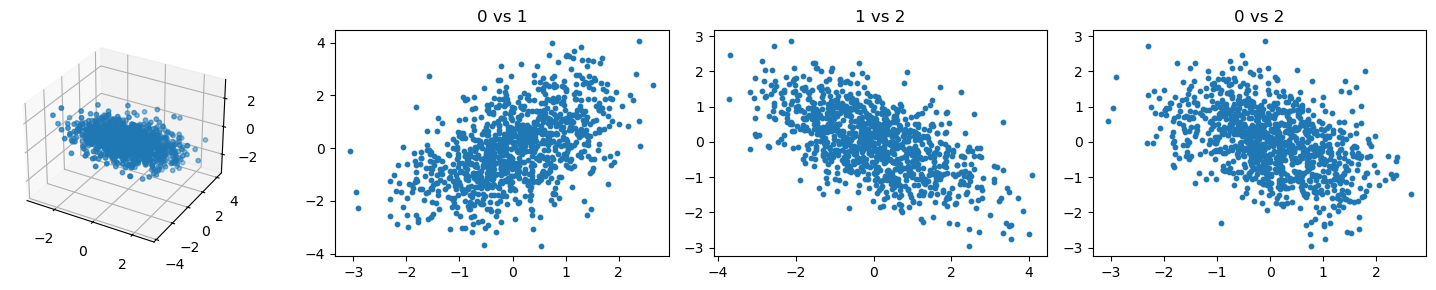

In [14]:
plot_3d_scatters(X,'',y=None)

In [15]:
# generate a list of random seeds to use for saving data

# rng = np.random.default_rng(42)
# num_seeds = 10
# random_seeds_lst = rng.integers(0, 2**20, size=num_seeds).tolist()

random_seeds_lst = [42,980]

In [18]:
# delete_dataset('anisotropic_gaussian','../all_data/')

data_gen_name = 'anisotropic_gaussian'
category_lst = ['density']

n_samples_lst = [1000,10000]
n_features_lst = [10,100,1000,10000]

# --- generate cov matrices ---
# currently randomly generated for each feature, but can be varied
random_seeds_cov = [56,1000] #corresponding to each random seed for data generating, we have a random seed to generate the covariance matrix
assert len(random_seeds_lst) == len(random_seeds_cov)
feature_covs_dict = {  (n_features,seed) : datasets.make_spd_matrix(n_dim=n_features, random_state=seed) for n_features, seed in product(n_features_lst,random_seeds_cov)}


for P = 10000 can consider generating cov matrix in a different way??
because .make_spd_matrix takes 10-40mins to generate one

In [19]:
# data save loop
for n_samples, n_features in product(n_samples_lst, n_features_lst):
    
    for sample_num,seed in enumerate(random_seeds_lst):
        
        cov_seed = random_seeds_cov[sample_num] #different from the data gen seed to avoid correlations
        cov = feature_covs_dict[(n_features,cov_seed)]
        X = random_covariance_gaussian(n_samples,n_features,cov,seed)
        
        params_dict = {
            'cov data gen method' : f'gen using sklearn datasets .make_spd_matrix',
            'n_dim' : n_features,
            'random_state' : cov_seed
        }
        
        try:
            save_dataset(X, 
                        generator=data_gen_name,
                        params=params_dict,
                        seed=seed,
                        category=category_lst,
                        extra_arrays={'cov' : cov}, 
                        root=DATA_ROOT)

        except:
            print('file already exists')
    
    print(n_samples, n_features, X.shape)

1000 10 (1000, 10)
1000 100 (1000, 100)
1000 1000 (1000, 1000)
1000 10000 (1000, 10000)
10000 10 (10000, 10)
10000 100 (10000, 100)
10000 1000 (10000, 1000)
10000 10000 (10000, 10000)


## plots

In [20]:
m = pd.read_csv(DATA_ROOT / "manifest.csv")
generator = 'anisotropic_gaussian'
m = m[(m.generator == generator)]
m

,dataset_id,generator,category,n_rows,n_cols,params_id,seed,extra_files
64,anisotropic_gaussian/params0/seed42_N1000_P10,anisotropic_gaussian,['density'],1000,10,params0,42,"[""cov_seed42.npy""]"
65,anisotropic_gaussian/params1/seed980_N1000_P10,anisotropic_gaussian,['density'],1000,10,params1,980,"[""cov_seed980.npy""]"
66,anisotropic_gaussian/params2/seed42_N1000_P100,anisotropic_gaussian,['density'],1000,100,params2,42,"[""cov_seed42.npy""]"
67,anisotropic_gaussian/params3/seed980_N1000_P100,anisotropic_gaussian,['density'],1000,100,params3,980,"[""cov_seed980.npy""]"
68,anisotropic_gaussian/params4/seed42_N1000_P1000,anisotropic_gaussian,['density'],1000,1000,params4,42,"[""cov_seed42.npy""]"
69,anisotropic_gaussian/params5/seed980_N1000_P1000,anisotropic_gaussian,['density'],1000,1000,params5,980,"[""cov_seed980.npy""]"
70,anisotropic_gaussian/params6/seed42_N1000_P10000,anisotropic_gaussian,['density'],1000,10000,params6,42,"[""cov_seed42.npy""]"
71,anisotropic_gaussian/params7/seed980_N1000_P10000,anisotropic_gaussian,['density'],1000,10000,params7,980,"[""cov_seed980.npy""]"
72,anisotropic_gaussian/params0/seed42_N10000_P10,anisotropic_gaussian,['density'],10000,10,params0,42,"[""cov_seed42.npy""]"
73,anisotropic_gaussian/params1/seed980_N10000_P10,anisotropic_gaussian,['density'],10000,10,params1,980,"[""cov_seed980.npy""]"


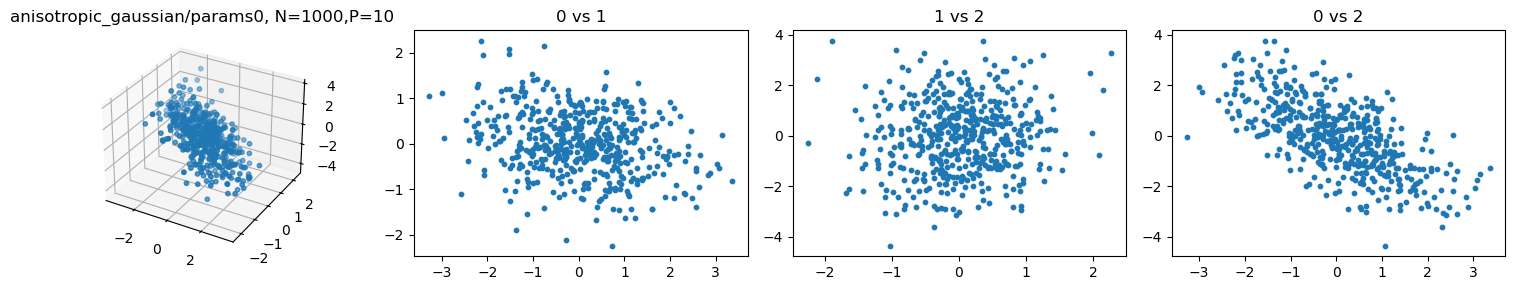

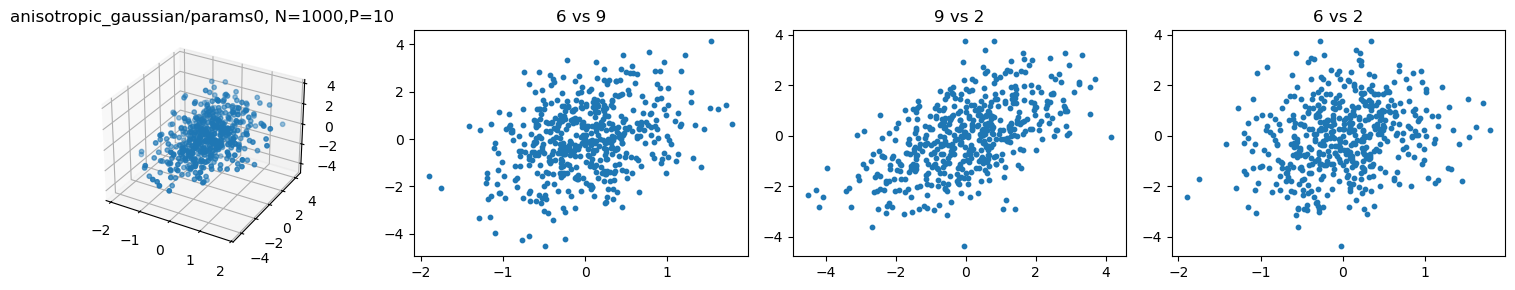

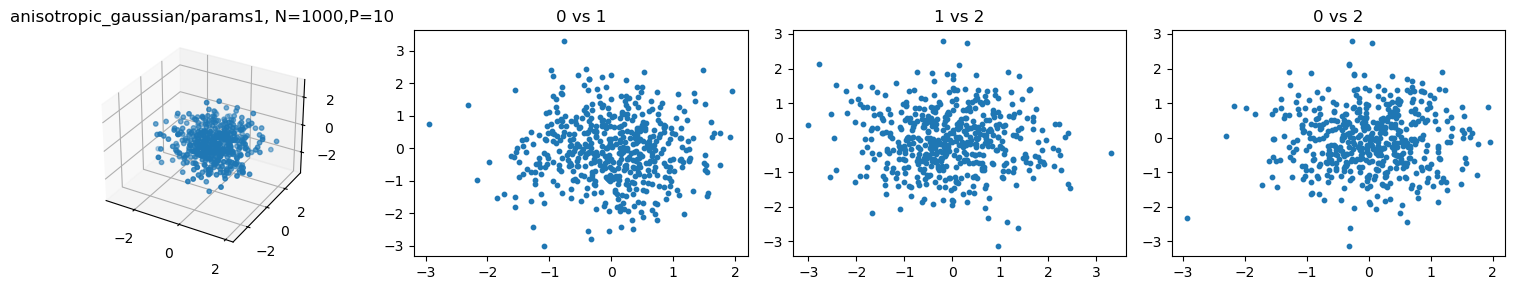

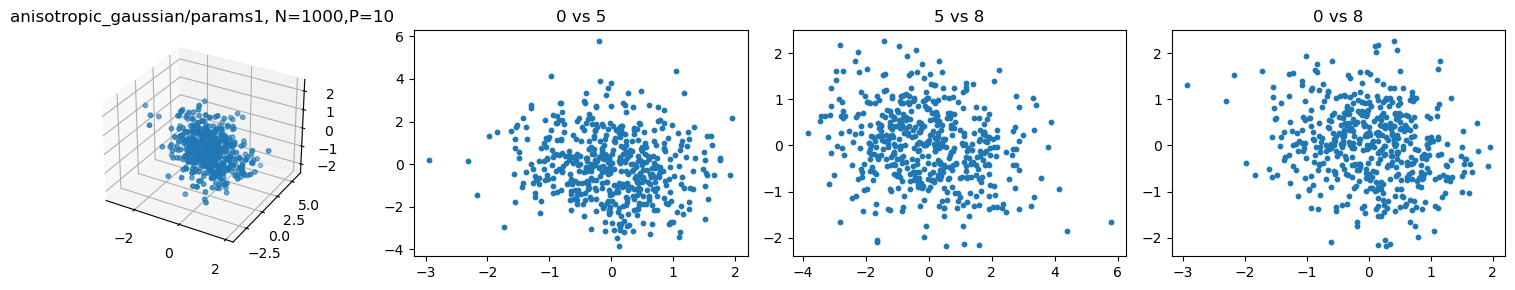

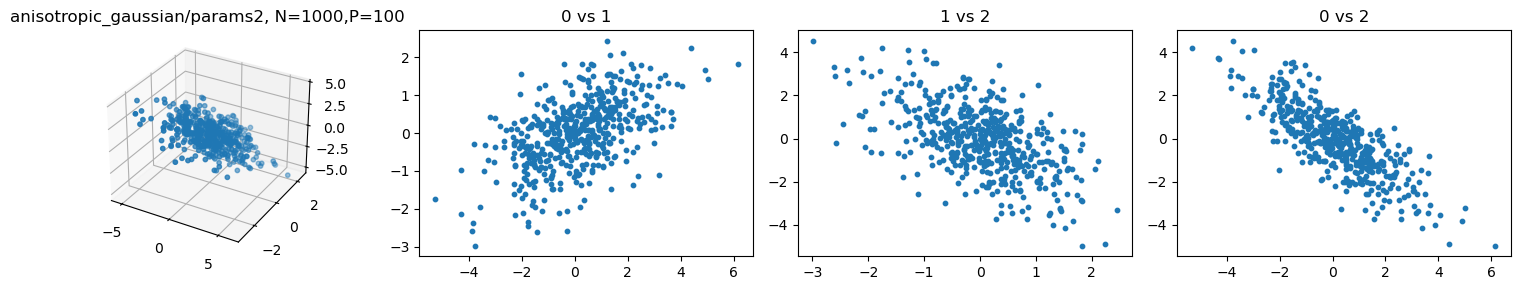

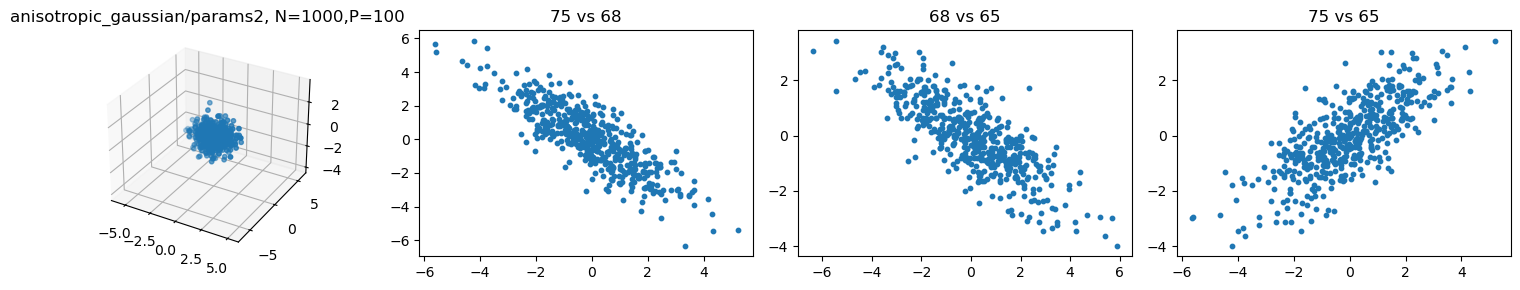

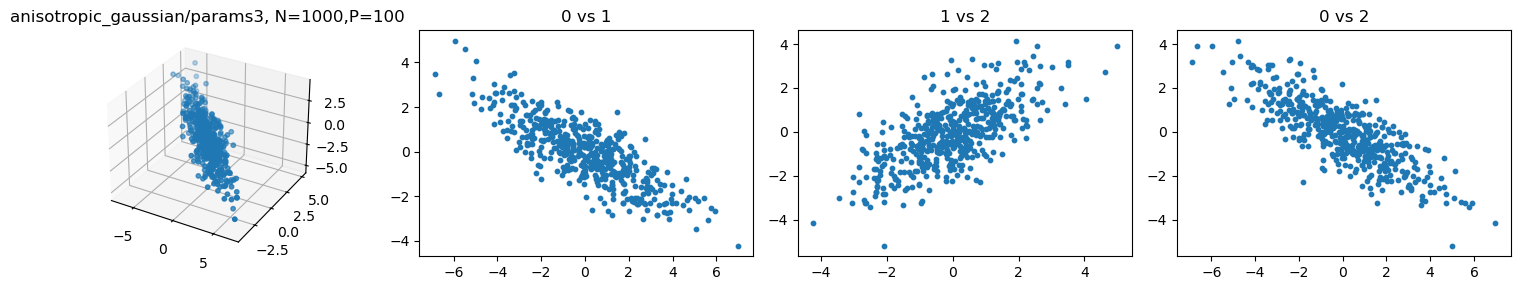

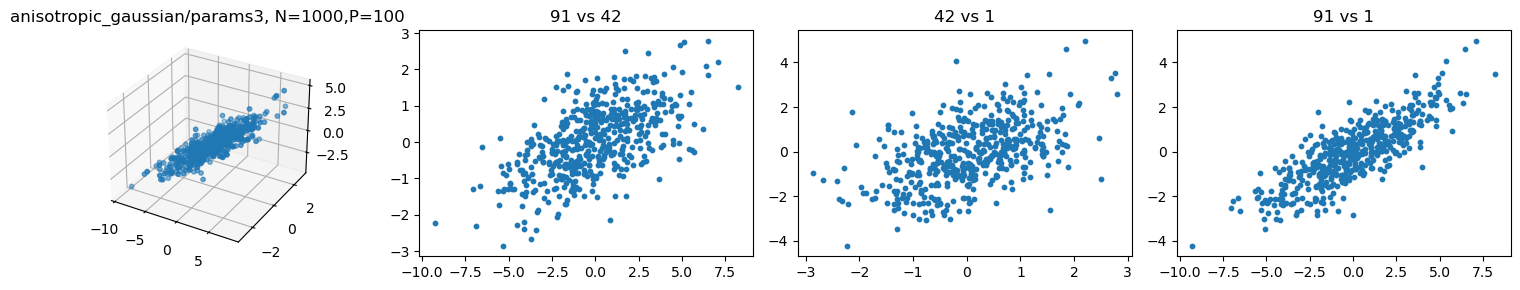

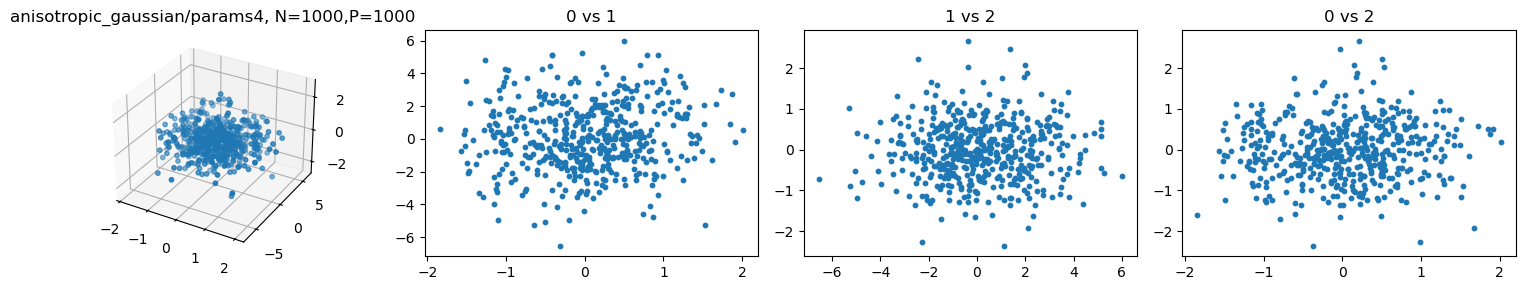

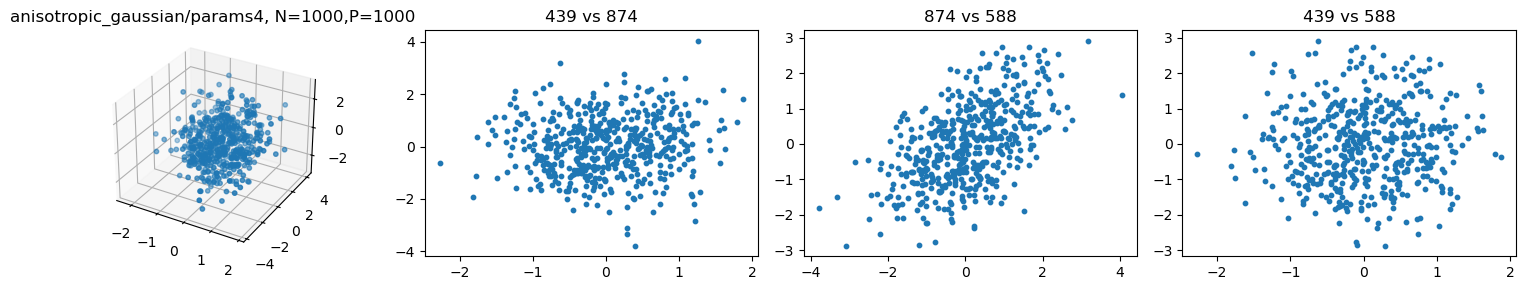

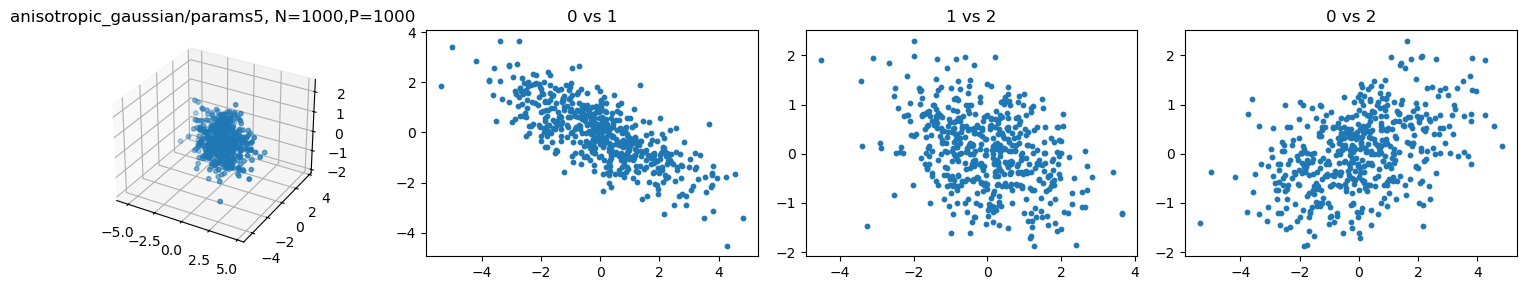

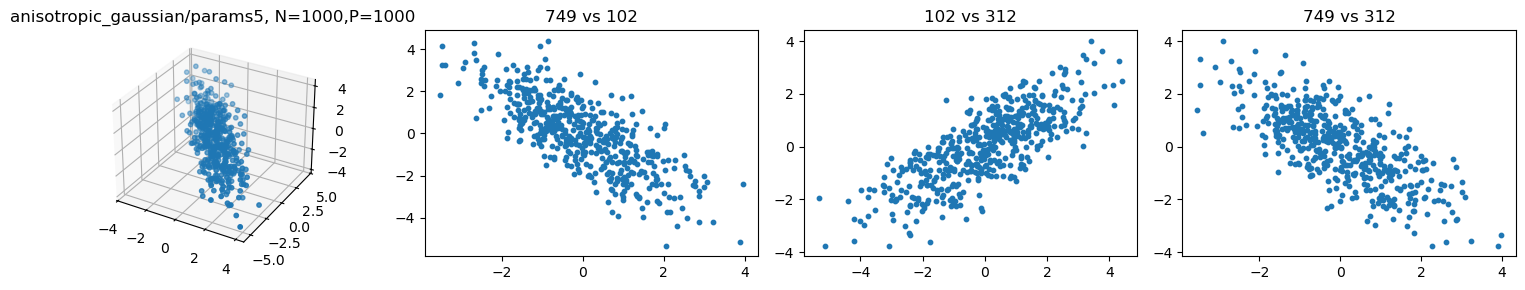

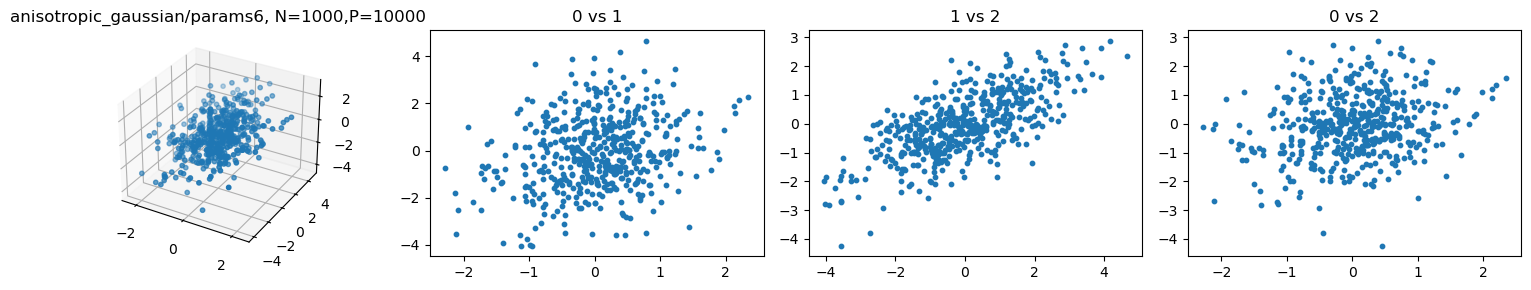

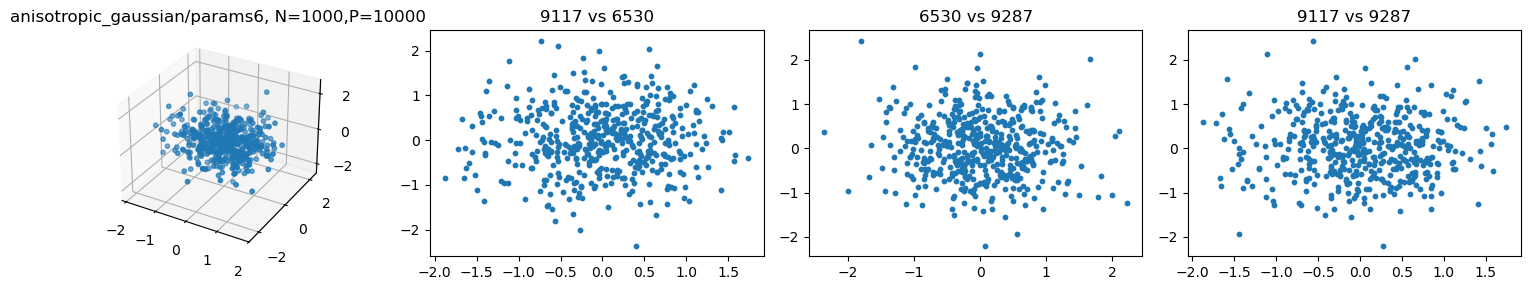

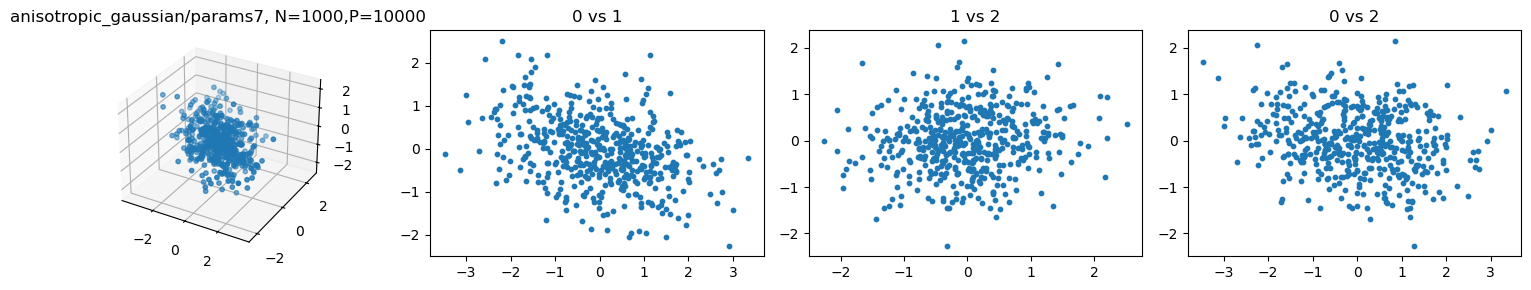

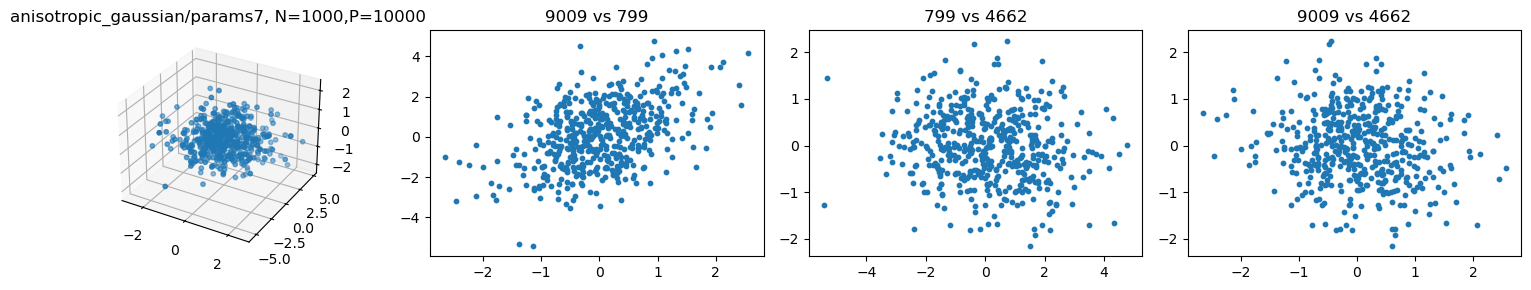

In [21]:
max_pts = 500
for r in m.groupby(["generator", "params_id"]).head(1).itertuples():
    X = np.load(DATA_ROOT / f"{r.dataset_id}.npy")
    if len(X) > max_pts:
        rng = np.random.default_rng(0)       
        X = X[rng.choice(len(X), max_pts, replace=False)]
    plot_3d_scatters(X, f"{r.generator}/{r.params_id}, N={r.n_rows},P={r.n_cols}")
    plot_3d_scatters(X, f"{r.generator}/{r.params_id}, N={r.n_rows},P={r.n_cols}",custom_inx=np.random.choice(r.n_cols, 3, replace=False))

array([10, 23, 17])